# Exercise 2.1: Exploratory analysis of the transformer dataset

This notebook works in Python and uses `transformer_data.csv` as requested.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

data_path = Path("../transformer_data.csv")
df = pd.read_csv(data_path)

df.head()

,time,Y,Ta,S,I
0,1,23.496733,7.083333,0.0,15.899541
1,2,22.720333,7.116667,0.0,15.861768
2,3,22.052700,7.216667,0.0,16.121469
3,4,21.538050,7.250000,0.0,15.447628
4,5,20.995033,7.316667,0.0,16.258319


In [2]:
summary = df[["Y", "Ta", "S", "I"]].describe().T
summary

,count,mean,std,min,25%,50%,75%,max
Y,168.0,27.650595,5.455816,19.828583,23.246383,26.066717,32.201554,38.923850
Ta,168.0,10.023115,2.916687,4.516667,7.866667,9.750000,12.000000,17.466667
S,168.0,214.432540,259.451647,0.000000,0.000000,65.416667,410.250000,755.833333
I,168.0,18.179092,3.662521,14.386027,15.635851,16.367102,21.212430,25.362786


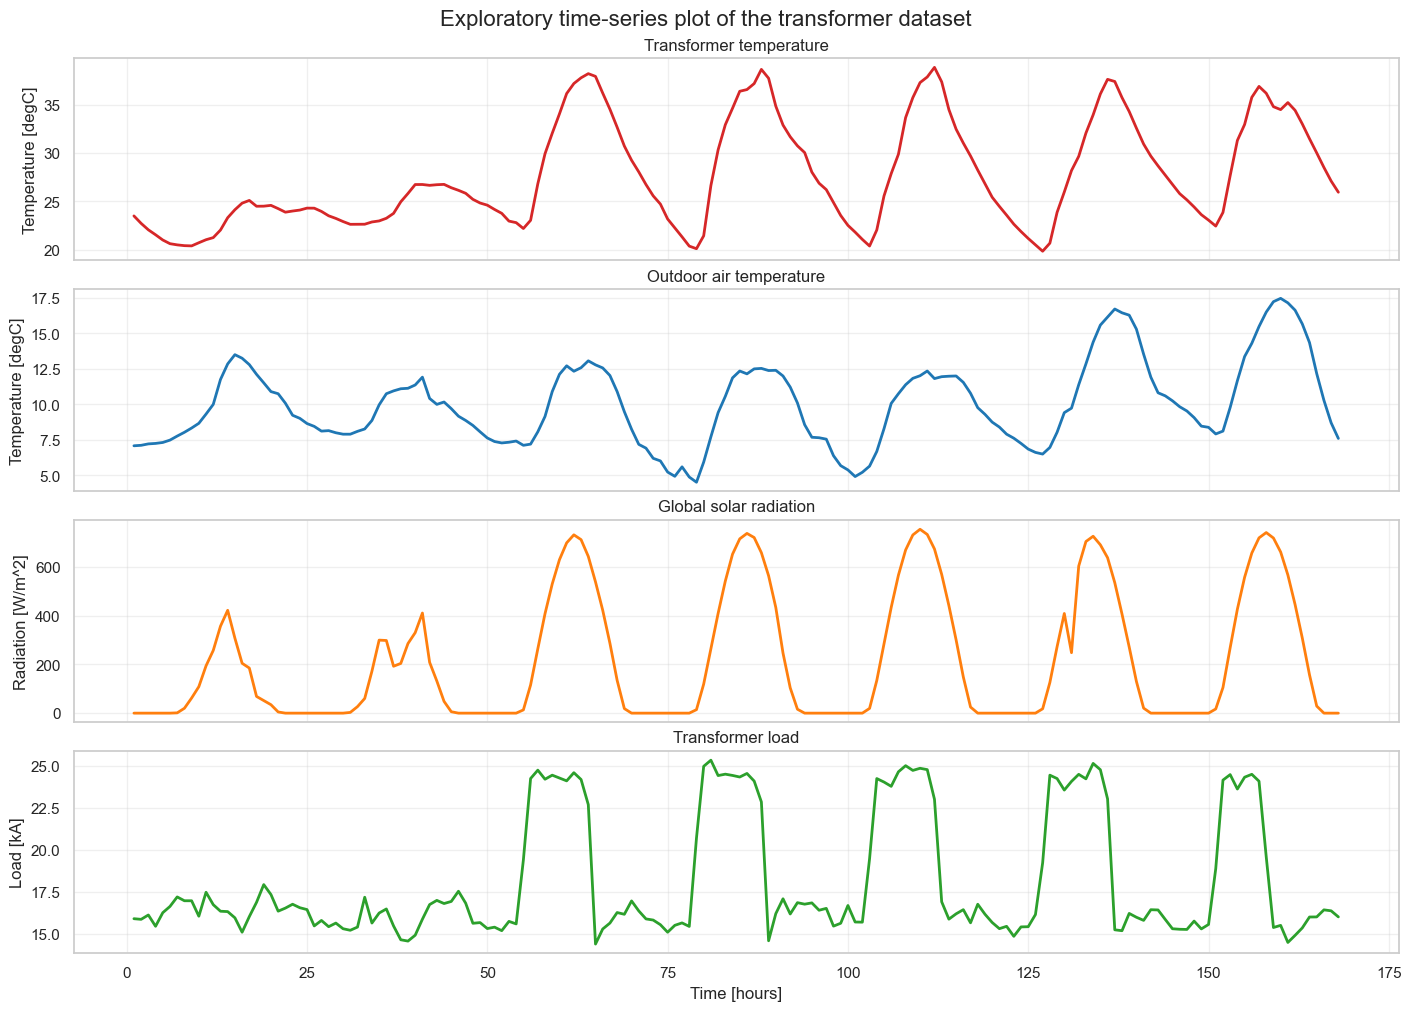

In [3]:
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True, constrained_layout=True)

series_config = [
    ("Y", "Transformer temperature", "tab:red", "Temperature [degC]"),
    ("Ta", "Outdoor air temperature", "tab:blue", "Temperature [degC]"),
    ("S", "Global solar radiation", "tab:orange", "Radiation [W/m^2]"),
    ("I", "Transformer load", "tab:green", "Load [kA]"),
]

for ax, (column, title, color, ylabel) in zip(axes, series_config):
    ax.plot(df["time"], df[column], color=color, linewidth=2)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Time [hours]")
fig.suptitle("Exploratory time-series plot of the transformer dataset", fontsize=16)
plt.show()

In [4]:
corr = df[["Y", "Ta", "S", "I"]].corr()
corr

,Y,Ta,S,I
Y,1.000000,0.778520,0.795264,0.384675
Ta,0.778520,1.000000,0.712500,0.162654
S,0.795264,0.712500,1.000000,0.631766
I,0.384675,0.162654,0.631766,1.000000


## Discussion

- The transformer temperature `Y` shows a clear repeating daily pattern with smooth rises and falls over time.
- `Y` tends to be high when both outdoor temperature `Ta` and solar radiation `S` are high, which suggests strong weather-related forcing.
- The relationship with `Ta` and `S` appears stronger than with load `I` in a same-time visual comparison.
- In this dataset, the sample correlations with `Y` are about `0.78` for `Ta`, `0.80` for `S`, and `0.38` for `I`.
- A practical modeling implication is that the state-space model should include exogenous effects from ambient conditions and may also need to account for thermal inertia, since the temperature evolves more smoothly than the inputs.

## Exercise 2.2: Estimate a 1-dimensional state-space model

The model is fitted in Python with a Kalman filter and maximum likelihood. I fix `C = 1` and `Sigma_x = 1` because in a 1-dimensional model the observation scale and the process-noise scale are otherwise not separately identifiable. The estimated process noise is therefore controlled by `G`, while `Sigma_y` is the observation-noise variance.


In [5]:
import numpy as np
from IPython.display import display
from scipy.optimize import minimize
from scipy.stats import probplot
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


def unpack_params(theta):
    """Map optimizer parameters to the 1D state-space matrices.

    theta = [A, B_Ta, B_S, B_I, log_G, log_sigma_y]
    with C = 1 and Sigma_x = 1 fixed for identifiability.
    """
    A = np.array([[theta[0]]], dtype=float)
    B = np.array([[theta[1], theta[2], theta[3]]], dtype=float)
    G = np.array([[np.exp(theta[4])]], dtype=float)
    C = np.array([[1.0]], dtype=float)
    Sigma_x = np.array([[1.0]], dtype=float)
    Sigma_y = np.array([[np.exp(theta[5]) ** 2]], dtype=float)
    Q = G @ Sigma_x @ G.T
    R = Sigma_y
    return A, B, G, C, Sigma_x, Sigma_y, Q, R


def kalman_filter_1d(theta, df):
    y = df["Y"].to_numpy(dtype=float)
    U = df[["Ta", "S", "I"]].to_numpy(dtype=float)
    n = len(y)

    A, B, G, C, Sigma_x, Sigma_y, Q, R = unpack_params(theta)
    a = A[0, 0]
    b = B[0]
    c = C[0, 0]
    q = Q[0, 0]
    r = R[0, 0]

    x_filt = np.full(n, np.nan)
    p_filt = np.full(n, np.nan)
    x_pred = np.full(n, np.nan)
    p_pred = np.full(n, np.nan)
    y_pred = np.full(n, np.nan)
    innovation = np.full(n, np.nan)
    innovation_var = np.full(n, np.nan)

    x_filt[0] = y[0] / c
    p_filt[0] = 10.0
    log_lik = 0.0

    for t in range(n - 1):
        x_pred[t + 1] = a * x_filt[t] + b @ U[t]
        p_pred[t + 1] = a * a * p_filt[t] + q

        y_pred[t + 1] = c * x_pred[t + 1]
        innovation[t + 1] = y[t + 1] - y_pred[t + 1]
        innovation_var[t + 1] = c * c * p_pred[t + 1] + r

        if innovation_var[t + 1] <= 0 or not np.isfinite(innovation_var[t + 1]):
            return None

        log_lik += -0.5 * (
            np.log(2 * np.pi)
            + np.log(innovation_var[t + 1])
            + innovation[t + 1] ** 2 / innovation_var[t + 1]
        )

        kalman_gain = p_pred[t + 1] * c / innovation_var[t + 1]
        x_filt[t + 1] = x_pred[t + 1] + kalman_gain * innovation[t + 1]
        p_filt[t + 1] = (1 - kalman_gain * c) * p_pred[t + 1]

    return {
        "log_lik": log_lik,
        "x_filt": x_filt,
        "p_filt": p_filt,
        "x_pred": x_pred,
        "p_pred": p_pred,
        "y_pred": y_pred,
        "innovation": innovation,
        "innovation_var": innovation_var,
    }


def kf_logLik_dt(theta, df):
    kf = kalman_filter_1d(theta, df)
    if kf is None:
        return -np.inf
    return kf["log_lik"]


def estimate_dt(start_par, df, bounds=None):
    def neg_log_lik(theta):
        if not np.all(np.isfinite(theta)):
            return 1e100
        value = kf_logLik_dt(theta, df)
        if not np.isfinite(value):
            return 1e100
        return -value

    return minimize(
        neg_log_lik,
        start_par,
        method="L-BFGS-B",
        bounds=bounds,
        options={"maxiter": 2000},
    )


In [6]:
# Parameter order: [A, B_Ta, B_S, B_I, log_G, log_sigma_y]
start_par = np.array([0.95, 0.05, 0.001, 0.02, np.log(0.5), np.log(0.5)])
bounds = [
    (0.0, 1.2),        # A
    (-5.0, 5.0),       # B_Ta
    (-0.1, 0.1),       # B_S
    (-5.0, 5.0),       # B_I
    (np.log(1e-4), np.log(20.0)),  # log_G
    (np.log(1e-4), np.log(20.0)),  # log_sigma_y
]

res = estimate_dt(start_par, df, bounds=bounds)
best_theta = res.x
kf = kalman_filter_1d(best_theta, df)
A, B, G, C, Sigma_x, Sigma_y, Q, R = unpack_params(best_theta)

llf = kf["log_lik"]
n_eff = len(df) - 1
k_params = len(best_theta)
aic = -2 * llf + 2 * k_params
bic = -2 * llf + np.log(n_eff) * k_params

param_table = pd.DataFrame(
    {
        "parameter": [
            "A", "B_Ta", "B_S", "B_I", "G", "C",
            "Sigma_x", "Sigma_y", "Q = G Sigma_x G'",
        ],
        "estimate": [
            A[0, 0], B[0, 0], B[0, 1], B[0, 2], G[0, 0], C[0, 0],
            Sigma_x[0, 0], Sigma_y[0, 0], Q[0, 0],
        ],
        "status": [
            "estimated", "estimated", "estimated", "estimated", "estimated", "fixed",
            "fixed", "estimated", "derived",
        ],
    }
)

print("Optimization success:", res.success)
print("Message:", res.message)
print(f"Log-likelihood: {llf:.2f}")
print(f"AIC: {aic:.2f}")
print(f"BIC: {bic:.2f}")
display(param_table)


Optimization success: True
Message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
Log-likelihood: -153.99
AIC: 319.99
BIC: 338.70


,parameter,estimate,status
0,A,7.351270e-01,estimated
1,B_Ta,1.115229e-01,estimated
2,B_S,2.321057e-03,estimated
3,B_I,3.153083e-01,estimated
4,G,6.051029e-01,estimated
5,C,1.000000e+00,fixed
6,Sigma_x,1.000000e+00,fixed
7,Sigma_y,1.000000e-08,estimated
8,Q = G Sigma_x G',3.661495e-01,derived


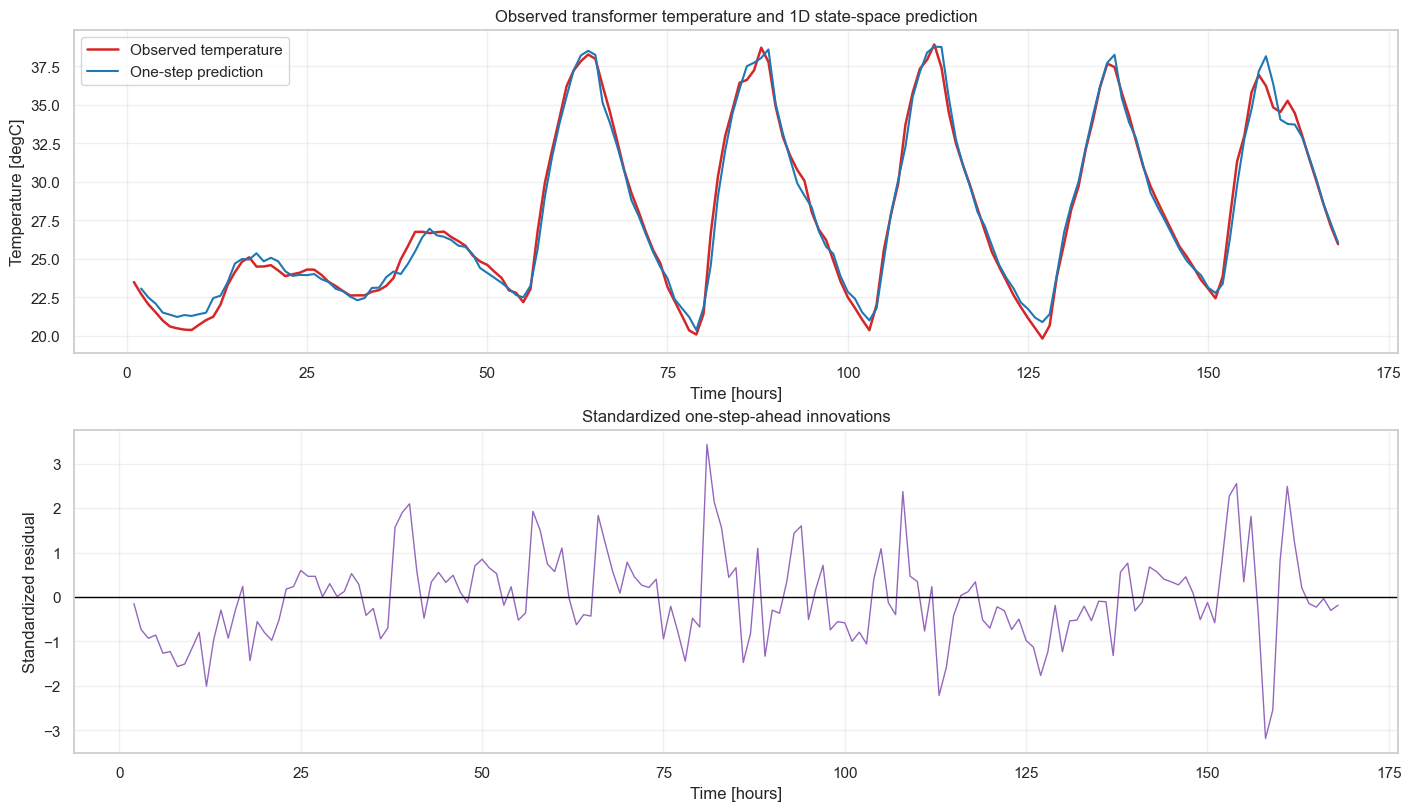

In [7]:
time = df["time"].to_numpy()
y = df["Y"].to_numpy(dtype=float)
std_resid = kf["innovation"] / np.sqrt(kf["innovation_var"])
diag_mask = np.isfinite(std_resid)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), constrained_layout=True)

axes[0].plot(time, y, label="Observed temperature", color="tab:red", linewidth=1.8)
axes[0].plot(time, kf["y_pred"], label="One-step prediction", color="tab:blue", linewidth=1.5)
axes[0].set_title("Observed transformer temperature and 1D state-space prediction")
axes[0].set_xlabel("Time [hours]")
axes[0].set_ylabel("Temperature [degC]")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(time, std_resid, color="tab:purple", linewidth=1.0)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Standardized one-step-ahead innovations")
axes[1].set_xlabel("Time [hours]")
axes[1].set_ylabel("Standardized residual")
axes[1].grid(True, alpha=0.3)

plt.show()


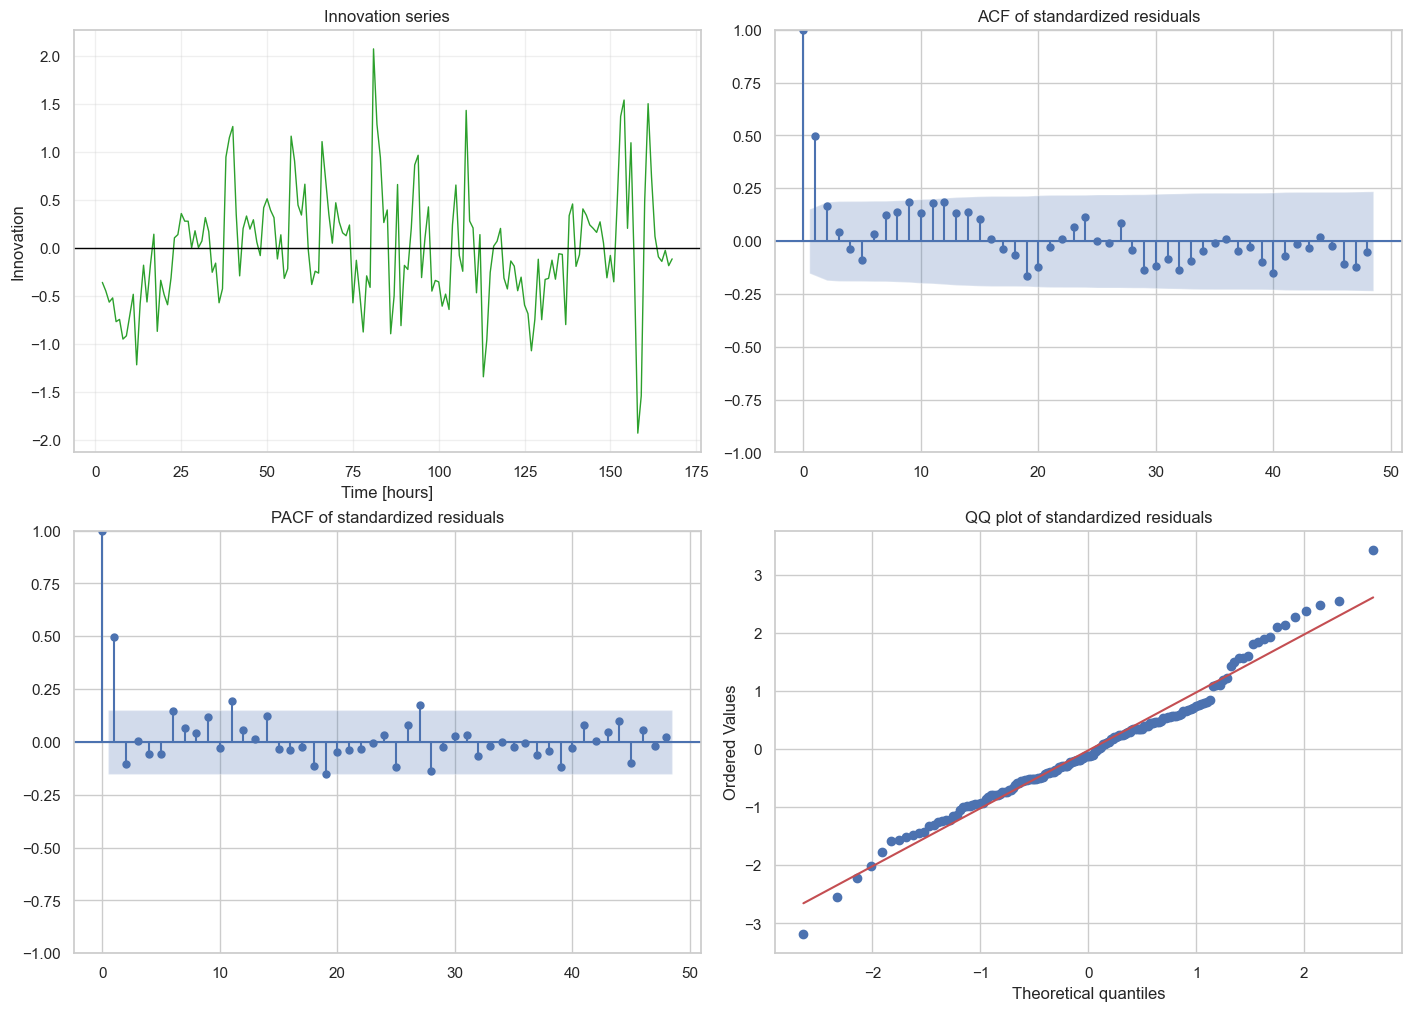

In [8]:
diagnostic_resid = std_resid[diag_mask]
innovation = kf["innovation"][diag_mask]

fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
axes = axes.ravel()

axes[0].plot(time[diag_mask], innovation, color="tab:green", linewidth=1.0)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Innovation series")
axes[0].set_xlabel("Time [hours]")
axes[0].set_ylabel("Innovation")
axes[0].grid(True, alpha=0.3)

plot_acf(diagnostic_resid, lags=min(48, len(diagnostic_resid) - 1), ax=axes[1])
axes[1].set_title("ACF of standardized residuals")

plot_pacf(diagnostic_resid, lags=min(48, len(diagnostic_resid) - 1), ax=axes[2], method="ywm")
axes[2].set_title("PACF of standardized residuals")

probplot(diagnostic_resid, dist="norm", plot=axes[3])
axes[3].set_title("QQ plot of standardized residuals")

plt.show()


### Discussion

- The estimate of `A` is below one, so the model has thermal persistence but is still mean-reverting after accounting for the inputs.
- The estimated effects of `Ta`, `S`, and `I` are positive, which is physically reasonable: higher outdoor temperature, stronger solar radiation, and larger load all increase the predicted transformer temperature.
- The residual diagnostics should be used to judge whether the 1D model is sufficient. Remaining autocorrelation or structured daytime residual peaks would indicate that a single latent state does not capture all thermal dynamics.
- In this fit, the observation-noise variance is very small relative to the process noise, so most short-term variation is absorbed through the latent state evolution rather than treated as measurement error.
